In [178]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches

from statsmodels.api import Logit, add_constant
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay


In [179]:
np.random.seed(4771)

N = 80

X1 = np.random.uniform(-2, 2, N)
X2 = np.random.uniform(-2, 2, N)

eta = 4*(X1**2) - 2*X2 + 1.5*X1*X2
p = 1 / (1 + np.exp(-eta))
y = (p > 0.5).astype(int)

X = np.column_stack((X1, X2))

In [180]:
#4.1

X_const = add_constant(X)
model = Logit(y, X_const).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.321423
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                   80
Model:                          Logit   Df Residuals:                       77
Method:                           MLE   Df Model:                            2
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                  0.2757
Time:                        22:40:12   Log-Likelihood:                -25.714
converged:                       True   LL-Null:                       -35.503
Covariance Type:            nonrobust   LLR p-value:                 5.603e-05
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4684      0.548      4.501      0.000       1.394       3.543
x1            -0.0329      0.309     -0.107      0.915      -0.639       0.573
x2            -1.6402      0.483     -3.393      0.001      -2.588      -0.693
==============================================================================
"""

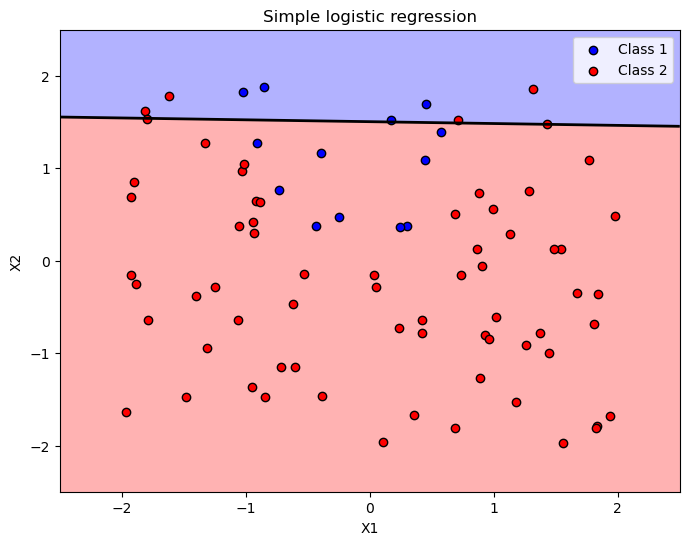

In [181]:
x1_grid, x2_grid = np.meshgrid(np.linspace(-2.5, 2.5, 200),
                               np.linspace(-2.5, 2.5, 200))

grid_const = np.column_stack((np.ones(x1_grid.ravel().shape),
                        x1_grid.ravel(), x2_grid.ravel()))
probs = model.predict(grid_const).reshape(x1_grid.shape)
grid = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))

# Scatter plot with decision boundary (probability = 0.5)
plt.figure(figsize=(8,6))
plt.contourf(x1_grid, x2_grid, probs, levels=[0,0.5,1], alpha=0.3, colors=['blue','red'])
plt.contour(x1_grid, x2_grid, probs, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X1[y==0], X2[y==0], c='blue', edgecolors='k', label='Class 1')
plt.scatter(X1[y==1], X2[y==1], c='red', edgecolors='k', label='Class 2')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Simple logistic regression')
plt.legend()
plt.show()

The picture itself looks promising, however we can observe that there a lot of blue dots inside of red region. When looking at statistical summary,it shows that the model is struggling due to a mismatch between its linear assumptions and the quadratic nature of the data.
The variable x1 has a p-value of 0.915, which means it is statistically irrelevant to this linear model.
In contrast, x2 is highly significant with a p-value of 0.001, as its relationship with the output is primarily linear.
Pseudo R^2 between 0.2 and 0.4 is often considered a "good" fit, but here it specifically highlights underfitting. 


In [182]:
#4.2 
poly = PolynomialFeatures(2, include_bias=True)
X_poly = poly.fit_transform(X)

model1 = Logit(y, X_poly).fit()
model1.summary()

         Current function value: 0.000000
         Iterations: 35


/usr/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                   80
Model:                          Logit   Df Residuals:                       74
Method:                           MLE   Df Model:                            5
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                   1.000
Time:                        22:40:12   Log-Likelihood:            -7.8980e-07
converged:                      False   LL-Null:                       -35.503
Covariance Type:            nonrobust   LLR p-value:                 6.325e-14
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7081   1.84e+04  -3.84e-05      1.000   -3.61e+04    3.61e+04
x1             0.3056   6.31e+04   4.84e-06      1.000   -1.24e+05    1.24e+05
x2          -125.5352   4.46e+04     -0.003      0.998   -8.76e+04    8.73e+04
x3           150.0233   6.53e+04      0.002      0.998   -1.28e+05    1.28e+05
x4            39.1655   3.98e+04      0.001      0.999    -7.8e+04    7.81e+04
x5            39.6900   2.49e+04      0.002      0.999   -4.88e+04    4.89e+04
==============================================================================

Complete Separation: The results show that there iscomplete separation or perfect prediction.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

Pseudo R-squared is 1.000, kind of meaning that the model has achieved 100% accuracy on the training data. Notice that the p-values for all variables are either equal or very close to 1, highlighting high relevance. However, the model says converged = False. The computer kept trying to make the coefficients larger to increase the likelihood, but eventually give up

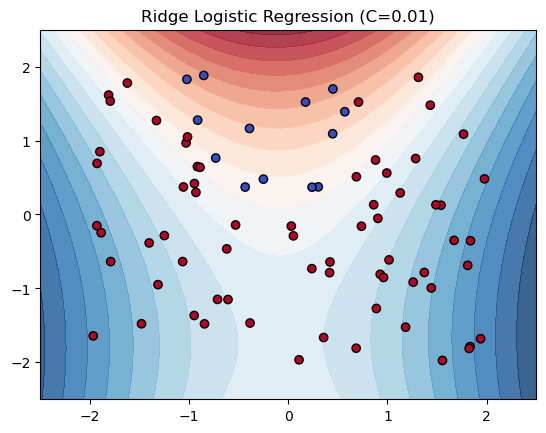

In [183]:
#4.3
clf_01 = LogisticRegression(C=0.01).fit(X_poly, y)
poly_grid = poly.transform(grid)
Z_01 = clf_01.predict_proba(poly_grid)[:, 1].reshape(x1_grid.shape)
plt.contourf(x1_grid, x2_grid, Z_01, levels=20, cmap='RdBu', alpha=0.8)
plt.scatter(X1, X2, c=y, edgecolors='k', cmap='coolwarm')
plt.title("Ridge Logistic Regression (C=0.01)")
plt.show()


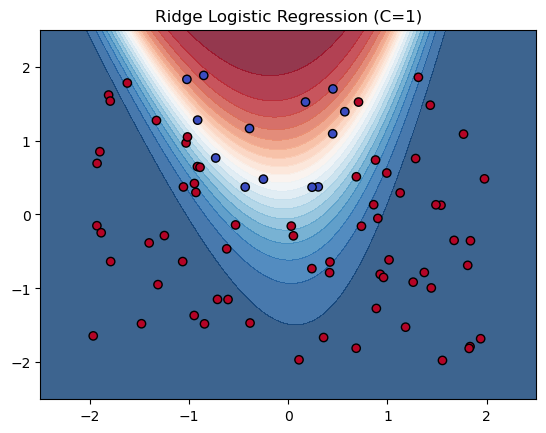

In [184]:
clf_1 = LogisticRegression(C=1).fit(X_poly, y)
poly_grid = poly.transform(grid)
Z_1 = clf_1.predict_proba(poly_grid)[:, 1].reshape(x1_grid.shape)
plt.contourf(x1_grid, x2_grid, Z_1, levels=20, cmap='RdBu', alpha=0.8)
plt.scatter(X1, X2, c=y, edgecolors='k', cmap='coolwarm')
plt.title("Ridge Logistic Regression (C=1)")
plt.show()

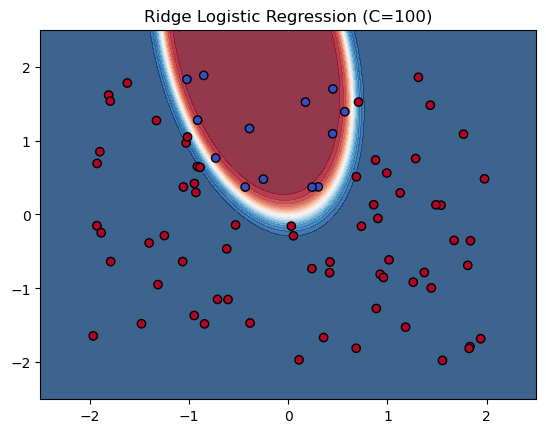

In [185]:
clf_100 = LogisticRegression(C=100).fit(X_poly, y)
poly_grid = poly.transform(grid)
Z_100 = clf_100.predict_proba(poly_grid)[:, 1].reshape(x1_grid.shape)
plt.contourf(x1_grid, x2_grid, Z_100, levels=20, cmap='RdBu', alpha=0.8)
plt.scatter(X1, X2, c=y, edgecolors='k', cmap='coolwarm')
plt.title("Ridge Logistic Regression (C=100)")
plt.show()

Regularization (Ridge) adds a penalty to the size of the coefficients. It essentially adds a cost to the model's "complexity". This stops the coefficients from running away to infinity. It also allows the algorithm to converge to a clean solution.

Small C (0.01) = Strong Penalty. The model is forced to be very conservative. The boundary is a very smooth, simple curve. The gradient is very wide and gradual. The model is less likely to "overfit" to specific points.
Large C (100) = Weak Penalty. The model is allowed to be much more aggressive. The boundary will wiggle more to perfectly separate every point. The gradient becomes very steep. Sometimes probability jumps from 0 to 1 almost instantly. This is very close to the unstability we saw in part 2.


In [186]:
#4.4
import matplotlib as mpl
def plot_ellipse(mean, cov, color, ax):
    v, w = np.linalg.eigh(cov)
    u = w[0] / np.linalg.norm(w[0])
    angle = np.arctan(u[1] / u[0])
    angle = 180 * angle / np.pi  # convert to degrees
    # filled Gaussian at 2 standard deviation
    ell = mpl.patches.Ellipse(
        mean,
        2 * v[0] ** 0.5,
        2 * v[1] ** 0.5,
        angle=180 + angle,
        facecolor=color,
        edgecolor="black",
        linewidth=2,
    )
    ell.set_clip_box(ax.bbox)
    ell.set_alpha(0.4)
    ax.add_artist(ell)


def plot_result(estimator, X, y, ax):
    cmap = colors.ListedColormap(["tab:red", "tab:blue"])
    DecisionBoundaryDisplay.from_estimator(
        estimator,
        X,
        response_method="predict_proba",
        plot_method="pcolormesh",
        ax=ax,
        cmap="RdBu",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        estimator,
        X,
        response_method="predict_proba",
        plot_method="contour",
        ax=ax,
        alpha=1.0,
        levels=[0.5],
    )
    y_pred = estimator.predict(X)
    X_right, y_right = X[y == y_pred], y[y == y_pred]
    X_wrong, y_wrong = X[y != y_pred], y[y != y_pred]
    ax.scatter(X_right[:, 0], X_right[:, 1], c=y_right, s=20, cmap=cmap, alpha=0.5)
    ax.scatter(
        X_wrong[:, 0],
        X_wrong[:, 1],
        c=y_wrong,
        s=30,
        cmap=cmap,
        alpha=0.9,
        marker="x",
    )
    ax.scatter(
        estimator.means_[:, 0],
        estimator.means_[:, 1],
        c="yellow",
        s=200,
        marker="*",
        edgecolor="black",
    )

    if isinstance(estimator, LinearDiscriminantAnalysis):
        covariance = [estimator.covariance_] * 2
    else:
        covariance = estimator.covariance_
    plot_ellipse(estimator.means_[0], covariance[0], "tab:red", ax)
    plot_ellipse(estimator.means_[1], covariance[1], "tab:blue", ax)

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set(xticks=[], yticks=[])

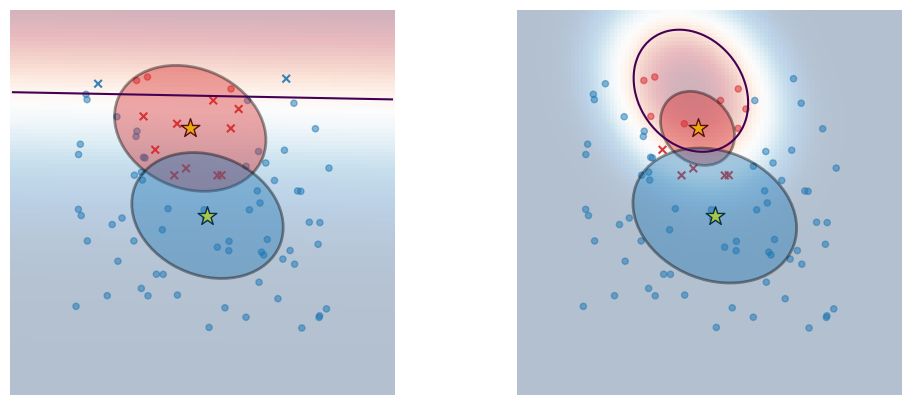

In [187]:
LDA = LinearDiscriminantAnalysis(store_covariance=True)
QDA = QuadraticDiscriminantAnalysis(store_covariance=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

LDA.fit(X, y)
plot_result(LDA, X, y, ax1)

QDA.fit(X, y)
plot_result(QDA, X, y, ax2)

plt.show()

4.5

The visualizations reveal that models with linear boundaries i.e Linear Logistic Regression and LDA both separate along straight line. Thus, they fail to separate the curved clusters, leading to high bias. An opposite result was shown by quadratic regression and QDA, captured the true data-generating process. Also they show that a non-linear assumptions are necessary here.

Linear Logistic Regression makes fewer assumptions about the distribution of the features, while LDA assumes the features are normally distributed with a shared covariance matrix. In this specific case, both perform poorly, because their shared "linear" assumption, and this cant compensate the quadratic nature of the data, regardless of their different underlying assumptions.

Quadratic regression assumes the underlying function is the polynomial with quadratic terms, while QDA generates a quadratic boundary based on the assumption that each class has its own normal distribution. Both perform well here because they can model the curvature. Though QDA is generally more efficient if the data is normally distributed, while Quadratic regression is more robust if the distribution is unknown.